# Thermal Lensing
#### PHY880 Final Presentation
Breck Meagher  
bnmeaghe@syr.edu  
  
April 20, 2026

---

In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('dark_background')
fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        "figure.autolayout": False,
        "font.family": "serif",
        #"font.serif": "DejaVu Serif",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

## 1. Introduction

High laser power is essential in many applications. In a Michelson, for example, detector sensitivity ultimately scales with the square root of the laser power, making higher power directly beneficial [\[3\]](vinet2009). Similarly, in applications such as the photoneutralization of hydrogen ion beams, the process is inherently inefficient due to the small cross section for hydrogen photoneutralization ($\sigma=3.48\times 10^{−21} \, \text{m}^2$), so achieving efficient neutralization requires ultra-high laser power [\[8\]](#genevriez2015).

However, even with high-quality optics made from materials with extremely low absorption, a small fraction of the incident laser power is inevitably absorbed either in the coating or within the bulk substrate. This absorbed power acts as a heat source, generating temperature gradients in the material [\[3\]](vinet2009).

Most materials have a refractive index that varies with temperature. As a result, when a light beam passes through a medium with a temperature gradient, the spatial variation in refractive index causes the heated region to behave like a lens, distorting the wavefront. This is called **thermal lensing**. The heating responsible for this effect can arise from absorption either in the optical coating or within the bulk of the substrate [\[4\]](#winkler1991).

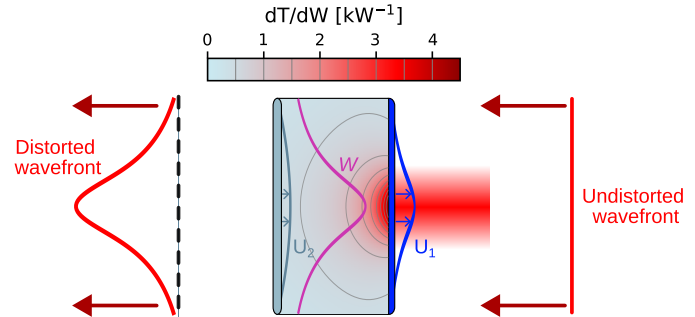

*Figure 1: Absorption of laser power creates a temperature gradient in the substrate, leading to a spatial variation in refractive index that distorts the transmitted wavefront. Diagram via Mitchell's thesis [\[7\]](#schiworski2024)*

---

### Adverse effects

If a cavity stores 750 kW of circulating optical power and the mirror coating has an absorption of 0.5 ppm, the absorbed power in the optic is:

$$
P_{\text{abs}} = 0.5 \times 10^{-6} \times 750\,\text{kW} \approx 375\,\text{mW}
$$

This absorbed power causes local heating in the coating, which generates thermal gradients in the substrate. These gradients produce **wavefront distortions** in both the carrier and sideband fields [\[1\]](#brooks2016).

As a result:

- The cavity becomes more difficult to mode-match, due to thermally induced changes in the effective optical mode.
- Length and alignment control systems are degraded, since thermal effects modify the optical response used for sensing and feedback.
- There is increased coupling of intensity and frequency noise into the readout signal through thermally induced optical path fluctuations.

> Understanding thermal lensing lets lets you mitigate its effects.
---

## 2. Steady State Thermal Gradients

In 1990, Patrice Hello and Jean-Yves Vinet published an analytical model for the thermal aberrations induced by high power beams on massive mirrors. They begin by deriving a steady state solution for the absorption of laser power in the optical coating and substrate. Their models depend on the assumption of an axially symmetric system and low heating (maximum temperature in the mirror is not much higher than the external temperature) [\[2\]](#hello1990).

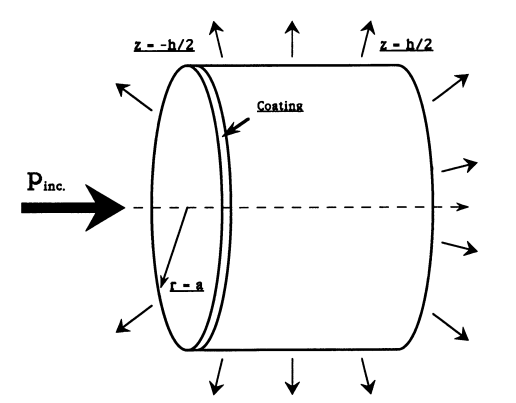

*Figure 2: Sketch of the massive mirror considered in the Hello-Vinet thermal model [\[2\]](#hello1990).*

The radiative heat loss of a surface at temperature T is given by:
$$
F=\sigma'[T^4-T_{ext}^4]
$$

where $\sigma'$ is the emissivity-corrected Stefan-Boltzmann constant. Under the assumption of low-heating ($(T_{max}-T_{ext})/T_{ext}\ll1$):
$$
F=4\sigma'T_{ext}^3\delta T
$$

with $\delta T=T-T_{ext}$. This linearizes the problem, and makes the contributions from the coating an the subtrate separable.

---

### 2.1 Coating absorption

**Game plan**: Expand the Gaussian optical heating from the laser into Bessel eigenmodes, then propagate each mode through the axial heat equation with radiative boundary conditions. This converts a 3D PDE into a set of independent 1D mode equations in $z$ that we can use to model thermal lensing [\[2\]](#hello1990)[\[3\]](vinet2009).  

Then we will recreate this plot!

---

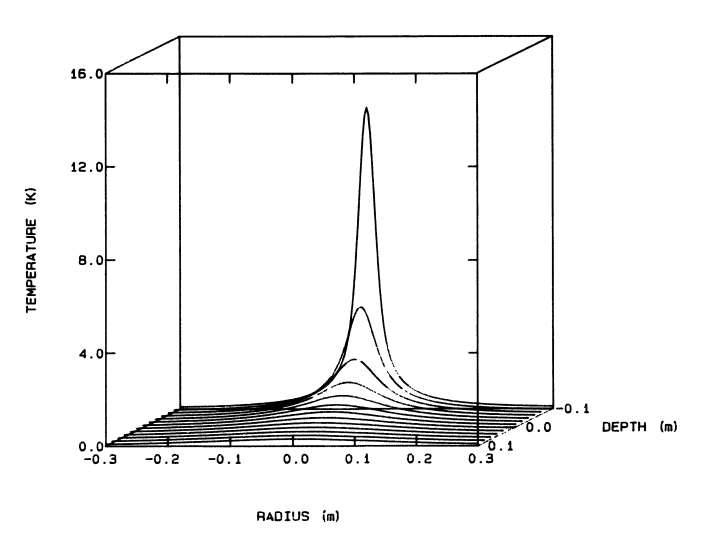

*Figure 3: Hello-Vinet's map of the steady state temperature field for a coating absorption of 1 W ($a=0.3$m and $h=0.2$ m)* [\[2\]](#hello1990)

In [2]:
import numpy as np
from scipy.special import j0, j1, jn_zeros
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D

### hello-vinet params
a = 0.3      # radius (m)
h = 0.2      # thickness (m)
K = 1.38     # thermal conductivity
w = 0.02     # beam waist (m)
P = 1.0      # absorbed power (W)

#### 1. Heat equation

The full heat equation is:

$$
\rho C \frac{\partial T}{\partial t} - K \Delta T = 0
$$

where:
- $T(t,r,z)$ is the temperature field
- $\rho$ is density
- $C$ is specific heat
- $K$ is thermal conductivity

---

#### 2. Steady-state decomposition

Consider a general steady state solution:

$$
T(r,z) = T_{\text{ext}} + T_{\infty}(r,z)
$$

where $T_{\infty}$ satisfies the Laplace equation because we are concerned with the steady state:

$$
\left(
\partial_r^2 + \frac{1}{r}\partial_r + \frac{1}{r^2}\partial_\phi^2 + \partial_z^2
\right) T_{\infty}(r,\phi,z) = 0
$$

---

#### 3. Optical heating (Gaussian beam)

The absorbed intensity profile for a Gaussian beam is:

$$
I(r) = \frac{2P}{\pi w^2} e^{-2r^2/w^2}
$$

This acts as a boundary heat flux at the coated surface.

In [3]:
def Ibeam(r):
    return (2 * P) / (np.pi * w**2) * np.exp(-2 * r**2 / w**2)

#### 4. Boundary conditions

##### (a) Radial edge $r=a$

$$
-K \frac{\partial T_{\infty}}{\partial r}(a,z) = 4\sigma' T_{\text{ext}}^3 T_{\infty}(a,z)
$$

##### (b) Front face $z = -h/2$

$$
-K \frac{\partial T_{\infty}}{\partial z}(r,-h/2) = \epsilon I(r)- 4\sigma' T_{\text{ext}}^3 T_{\infty}(r,-h/2)
$$

##### (c) Back face $z = h/2$

$$
-K \frac{\partial T_{\infty}}{\partial z}(r,h/2) = 4\sigma' T_{\text{ext}}^3 T_{\infty}(r,h/2)
$$

---

#### 5. Mode (eigenfunction) expansion

Because the system is axially symmetric, expand:

$$
T_{\infty}(r,\phi,z)= \sum_{n,s} T_{n,s}(z)\,J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)\cos(n\phi + \phi_n)
$$

where:
- $J_n$ are Bessel functions of the first kind
- $\zeta_{n,s}$ are eigenvalues from boundary conditions (Sturm-Liouville problem)

---

#### 6. Radial eigenvalue condition

Let $\chi_e = 4\sigma' T_{\text{ext}}^3 a/{K}$.

With $T \sim J_n(kr)$:

- $T(a) = J_n(ka)$  
- $\partial_r T|_{a} = k J_n'(ka)$  

Radial edge losses impose:

$$
\zeta J_n'(\zeta) + \chi_e J_n(\zeta) = 0
$$

giving discrete modes $\zeta_{n,s}$.

In [4]:
mMax = 30 # number of eigenfunctions (modes) i want to consider
k_vals = jn_zeros(1, mMax) / a # generate eigenvalues

#### 7. Fourier–Bessel expansion of intensity

The absorbed intensity is expanded in the same basis as a Fourier-Bessel (FB) series:

$$
I(r) = \frac{P}{\pi a^2}\sum_{s>0} p_{n,s}J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)
$$

with coefficients obtained by projection:

$$
p_{n,s} \propto\int_0^a I(r)\,J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)r\,dr
$$

In [5]:
def compute_pm(k):
    integrand = lambda r: r * Ibeam(r) * j0(k * r)
    return quad(integrand, 0, a, limit=100)[0]

pm_vals = np.array([compute_pm(k) for k in k_vals])
norm_vals = (a**2 / 2) * (j0(k_vals * a))**2


#### 8. Axial equation

Each mode satisfies:

$$
\frac{d^2 T_{n,s}}{dz^2}- \left(\frac{\zeta_{n,s}}{a}\right)^2 T_{n,s} = 0
$$

so:

$$
T_{n,s}(z)= A_{n,s} e^{\zeta_{n,s} z/a}+ B_{n,s} e^{-\zeta_{n,s} z/a}
$$

---

#### 9. Final solution

Applying both surface radiation boundary conditions gives:

$$
\boxed{
T_{\infty}(r,\phi,z)=\sum_{n,s}T_{n,s}(z)\,J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)\cos(n\phi + \phi_n)
}
$$

with $T_{n,s}(z)$ determined by the balance of:
- absorbed optical power $\epsilon I(r)$
- radiative losses $4\sigma' T_{\text{ext}}^3 T$

---

In [6]:
def T(r, z):
    total = 0.0
    for m in range(mMax):
        k = k_vals[m]
        total += (pm_vals[m] / norm_vals[m]) * \
                 j0(k * r) * \
                 np.cosh(k * (z + h/2)) / np.sinh(k * h)
    return total / K

# radial coordinate
r_vals = np.linspace(-a, a, 150)
z_vals = np.linspace(-h/2, h/2, 100)
R, Z = np.meshgrid(r_vals, z_vals)

# symmetry: T(r,z) = T(|r|,z)
T_vals = np.vectorize(lambda r, z: T(abs(r), z))(R, Z)

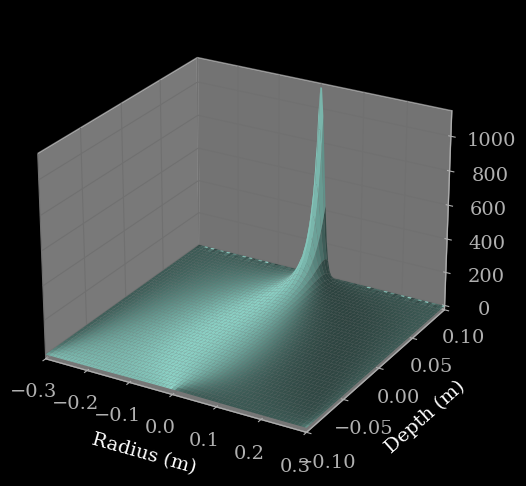

In [7]:
### PLOTTING
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(R, Z, T_vals, rstride=2, cstride=2)

ax.set_xlabel('Radius (m)', labelpad=10)
ax.set_ylabel('Depth (m)', labelpad=10)
ax.set_zlabel('Temperature (K)', labelpad=20)

ax.tick_params(axis='x', pad=5)
ax.tick_params(axis='y', pad=5)
ax.tick_params(axis='z', pad=10)

ax.set_xlim(-a, a)
ax.set_ylim(-h/2, h/2)

ax.view_init(elev=25, azim=-60)

plt.show()

### 2.2 Bulk Absorption

The mathematical process for bulk absorption is very similar to the coating absorption process. Instead of heat only being injected at the boundary, heat can now come from other points within the volume. This means that the solutions consist of the same set of eigenfunctions, with different amplitudes.

Now assume heat is generated throughout the substrate due to weak optical absorption:

---

#### 1. Volumetric heat source

The optical intensity decays weakly in $z$:
$$
I(r,z) = I(r)\, e^{-\beta (z + h/2)}
$$

For small $\beta h \ll 1$, approximate a uniform bulk source along $z$:
$$
Q(r,z) \approx \beta I(r)
$$

---

#### 2. Heat equation
For each angular mode:
$$
\left(\partial_r^2 + \frac{1}{r}\partial_r + \frac{1}{r^2}\partial_\phi^2 + \partial_z^2\right) T=-\frac{\beta}{K} I_n(r)\cos(n\phi + \phi_n)
$$

---

#### 3. Mode expansion

Use the same eigenbasis as before:
$$
T_n(r,\phi,z)= \sum_s T_{n,s}(z)\,J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)\cos(n\phi + \phi_n)
$$

- same $\zeta_{n,s}$ (edge boundary condition unchanged)
- same projection coefficients $p_{n,s}$

---

#### 4. Solution

Because the source is **independent of $z$**, we split:

* Particular (bulk-driven) solution
$$
T^{(1)}_{n,s}
\propto \frac{\beta P}{\pi K} \frac{p_{n,s}}{\zeta_{n,s}^2}
$$

* Homogeneous correction (boundary-enforced)
$$
T^{(2)}_{n,s}(z)
\propto \cosh\!\left(\frac{\zeta_{n,s} z}{a}\right)
$$

The full solution is then:
$$
\boxed{
T_{n,s}(z)=\frac{\beta P}{\pi K}\frac{p_{n,s}}{\zeta_{n,s}^2}\left[1-\chi \frac{\cosh(\zeta_{n,s} z/a)}{d_{1,n,s}}\right]
}
$$

---

## Finesse Comparison

Now that we've done the work to map induced thermal gradients in our big mirror, let's compare to the Finesse3 example [\[10\]](#hello_vinet_finesse).

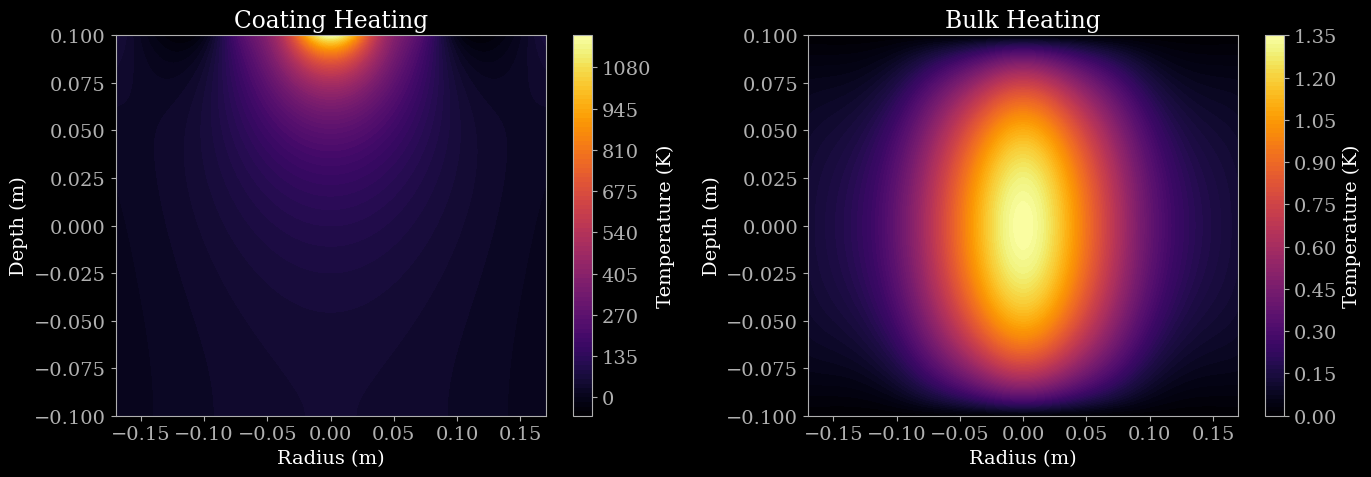

In [8]:
### finesse example params
a = 0.17     # mirror radius
h = 0.2      # mirror thickness
w = 53e-3    # spot size radius
K = 1.38     # thermal conductivity
P = 0.6     # absorbed power (W)

# radial coordinate
r_vals = np.linspace(-a, a, 150)
z_vals = np.linspace(-h/2, h/2, 100)
R, Z = np.meshgrid(r_vals, z_vals)

pm_vals = np.array([compute_pm(k) for k in k_vals])
norm_vals = (a**2 / 2) * (j0(k_vals * a))**2
T_vals = np.vectorize(lambda r, z: T(abs(r), z))(R, Z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# coating absorption
cf1 = ax1.contourf(R, Z, T_vals, levels=100, cmap='inferno')
fig.colorbar(cf1, ax=ax1, label='Temperature (K)')

ax1.set_xlabel('Radius (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Coating Heating')


# bulk absorption
def T_bulk(r, z):
    total = 0.0
    for m in range(mMax):
        k = k_vals[m]
        total += (pm_vals[m] / (norm_vals[m] * k**2)) * \
                 j0(k * r) * \
                 (1 - np.cosh(k * z) / np.cosh(k * h/2))
    return total / K

T_vals2 = np.vectorize(lambda r, z: T_bulk(abs(r), z))(R, Z)

cf2 = ax2.contourf(R, Z, T_vals2, levels=100, cmap='inferno')
fig.colorbar(cf2, ax=ax2, label='Temperature (K)')

ax2.set_xlabel('Radius (m)')
ax2.set_ylabel('Depth (m)')
ax2.set_title('Bulk Heating')

plt.tight_layout()
plt.show()

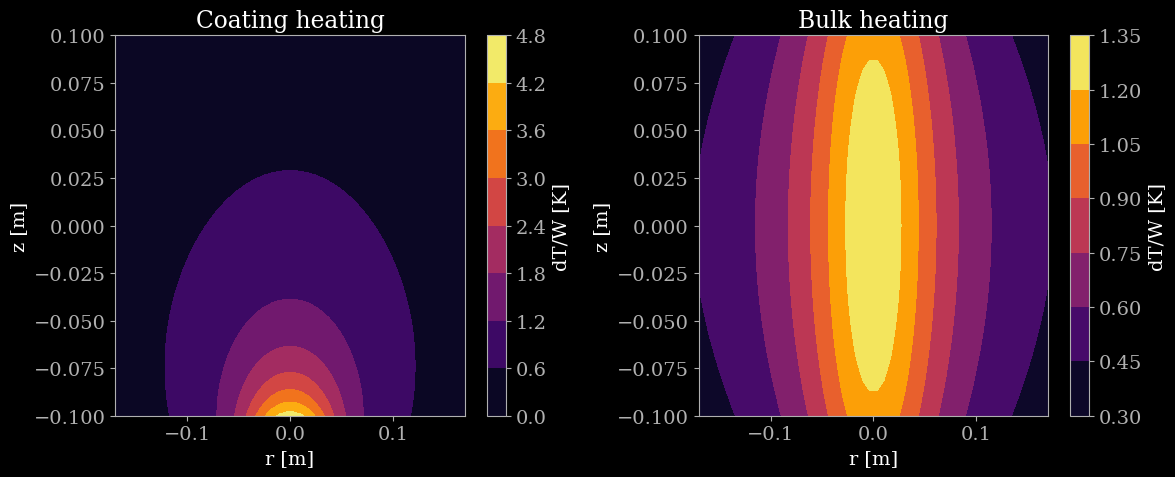

In [9]:
# Code via the finesse3 documentation example set accessible at https://finesse.ifosim.org/docs/latest/usage/thermal_effects/hello_vinet.html
import finesse
import finesse.thermal.hello_vinet as hv
from finesse.materials import FusedSilica

a = 0.17  # mirror radius
h = 0.2   # mirror thickness
w = 53e-3 # spot size radius

r = np.linspace(-a, a, 50)
z = np.linspace(-h/2, h/2, 100)

material = FusedSilica

T_coat_per_W, T_bulk_per_W = hv.substrate_temperatures_HG00(
    r, z, a, h, w, material
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# coating
c1 = ax1.contourf(r, z, T_coat_per_W, levels=7, cmap='inferno')
ax1.set_title("Coating heating")
ax1.set_xlabel("r [m]")
ax1.set_ylabel("z [m]")
fig.colorbar(c1, ax=ax1, label="dT/W [K]")

# bulk
c2 = ax2.contourf(r, z, T_bulk_per_W, levels=7, cmap='inferno')
ax2.set_title("Bulk heating")
ax2.set_xlabel("r [m]")
ax2.set_ylabel("z [m]")
fig.colorbar(c2, ax=ax2, label="dT/W [K]")

plt.tight_layout()
plt.show()

## 3. Steady State Thermal Lensing

The temperature field inside the substrate produces a spatially varying refractive index via the thermo-optic effect. Since $n(r,z)$ is no longer uniform, light rays experience a spatially varying optical path. This acts like a lens, called **thermal lensing**.

---

#### 1. Thermo-optic relation

A temperature change induces a refractive index change:

$$
\delta n(r,z) = \frac{dn}{dT} \, T(r,z)
$$

where $\frac{dn}{dT}$ is the thermo-optic coefficient.

---

#### 2. Excess optical path (EOP)

The thermal lens is quantified by the excess optical path:

$$
Z(r) = \frac{dn}{dT} \int_{-h/2}^{h/2} T(r,z)\, dz
$$

This is the accumulated phase delay for a ray crossing the substrate.

---

#### 3. Interpretation in terms of earlier solutions

Since $T(r,z)$ is already expressed as a sum of Bessel modes:

$$
T(r,\phi,z)= \sum_{n,s} T_{n,s}(z)\,J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)\cos(n\phi+\phi_n)
$$

the thermal lens becomes:

$$
Z(r) \propto \sum_{n,s}
\left(\int_{-h/2}^{h/2} T_{n,s}(z)\,dz\right)
J_n\!\left(\frac{\zeta_{n,s} r}{a}\right)
$$

if you neglect diffraction inside the substrate, so rays propagate straight through in $z$.

---

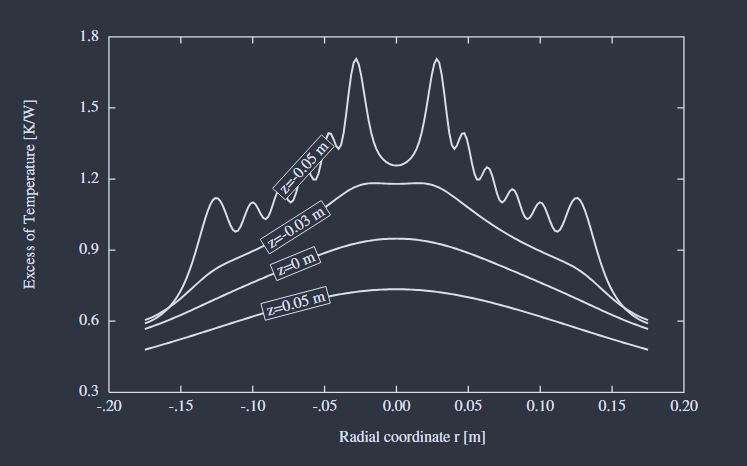  
  
*Figure 4: Temperature at different substrate depths for a $LG_{5,5}$ mode* [\[3\]](#vinet2009).  

In [24]:
from ipywidgets import interact, FloatSlider

def plot_beam_size(w_mm=30):
    w = w_mm * 1e-3

    Z_coat, Z_bulk = hv.thermal_lenses_HG00(
        r, a, h, w, FusedSilica
    )

    Z_total = Z_coat + Z_bulk

    plt.figure(figsize=(6,4))
    plt.plot(r, Z_total, label=f"Total OPD (w={w_mm:.1f} mm)")
    plt.xlabel("r [m]")
    plt.ylabel("OPD [m]")
    plt.title("Thermal lens vs beam size")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(
    plot_beam_size,
    w_mm=FloatSlider(min=5, max=80, step=1, value=30)
)

interactive(children=(FloatSlider(value=30.0, description='w_mm', max=80.0, min=5.0, step=1.0), Output()), _do…

<function __main__.plot_beam_size(w_mm=30)>

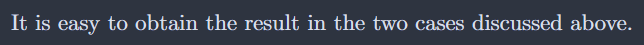  
*Figure 5: A direct quote from page 32 of Vinet's 2009 publication "On Special Optical Modes..."* [\[3\]](#vinet2009).  

---

## Fixing Thermal Lensing
Absorption in the test masses of LIGO is actively corrected for by the Thermal Compensation System (TCS). In practice, the TCS operates as a feedback-controlled system that continuously monitors and counteracts thermally induced changes in the optics [\[1\]](#brooks2016).

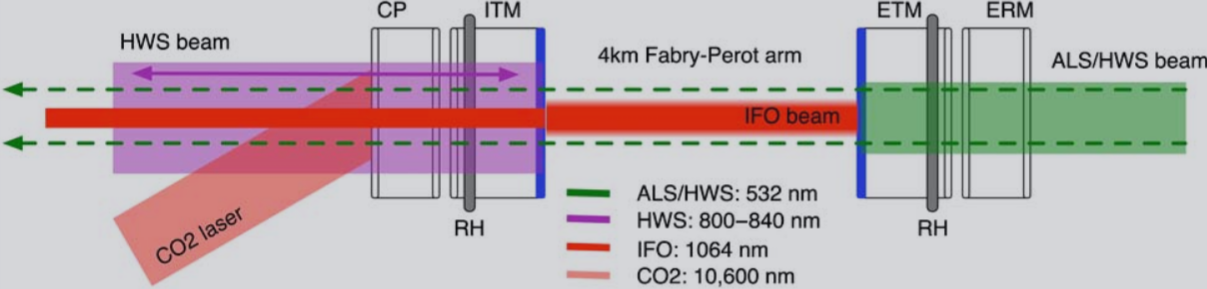  
*Figure 7: aLIGO Thermal Compensation System (TCS) overview* [\[1\]](#brooks2016).

The TCS consists of a set of sensors and actuators. It measures thermally induced wavefront distortions using dedicated sensors (such as Hartmann wavefront sensors), and applies corrective heating to adjust the mirrors’ radius of curvature via ring heaters. It also uses CO$_2$ lasers to correct wavefront distortions [\[1\]](#brooks2016)[\[6\]](#brooks2009).

### Thermal effects in the lab

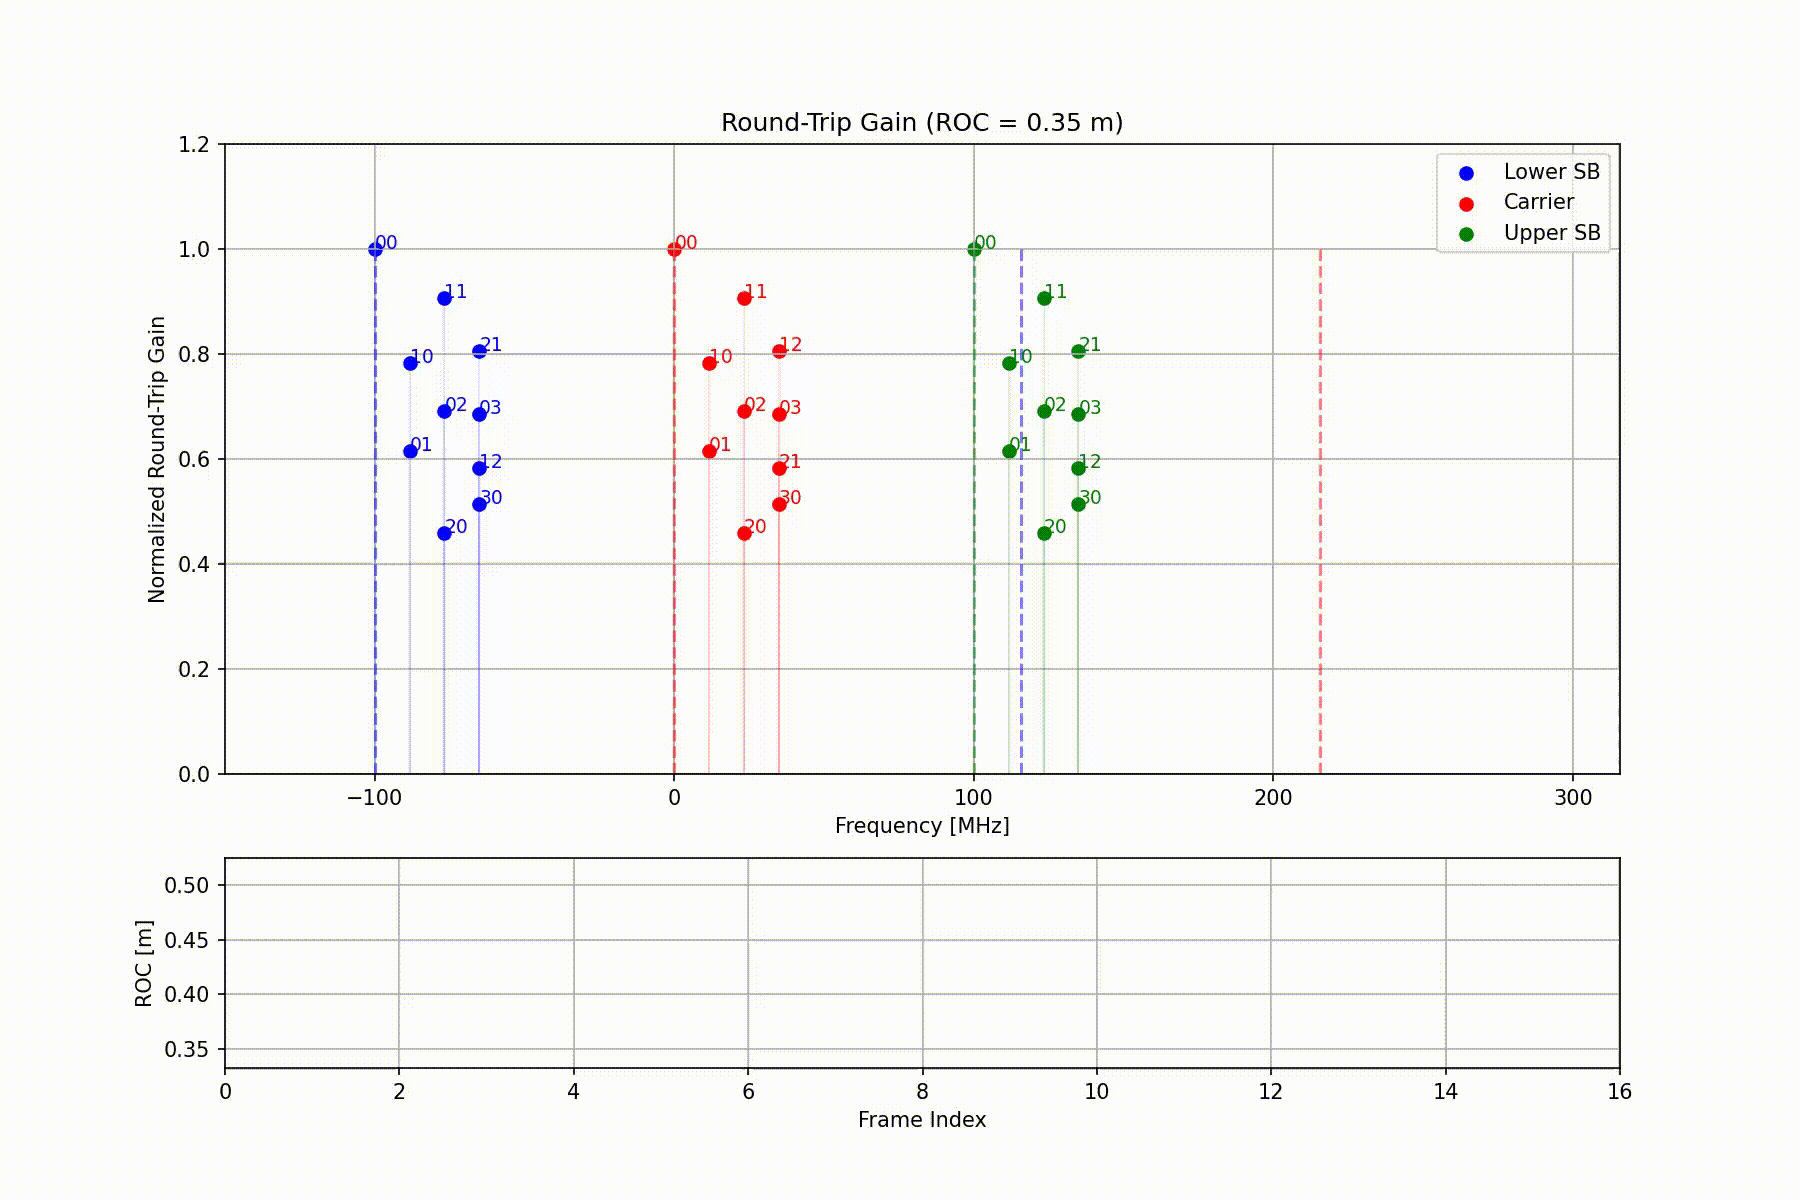

*Figure 6: Thermal lensing in the photoneutralization cavity can change the effective radius of curvature of the mirrors. This alters the cavity’s transverse mode spacing (TMS), which can cause the fundamental TEM$_{00}$ mode to overlap with higher-order spatial modes. As a result, the cavity becomes more difficult to control.*

---

## References

<a id="brooks2016"></a>
[1] A. F. Brooks, B. Abbott, M. A. Arain, et al.,  
*“Overview of Advanced LIGO Adaptive Optics,”*  
Applied Optics **55**, 8256 (2016).  
https://doi.org/10.1364/AO.55.008256

<a id="hello1990"></a>
[2] P. Hello and J.-Y. Vinet,  
*“Analytical Models of Thermal Aberrations in Massive Mirrors Heated by High Power Laser Beams,”*  
Journal de Physique **51**, 1267–1282 (1990).  
https://doi.org/10.1051/jphys:0199000510120126700

<a id="vinet2009"></a>
[3] J.-Y. Vinet,  
*“On Special Optical Modes and Thermal Issues in Advanced Gravitational Wave Interferometric Detectors,”*  
Living Reviews in Relativity **12**, 5 (2009).  
https://doi.org/10.12942/lrr-2009-5

<a id="winkler1991"></a>
[4] W. Winkler, K. Danzmann, A. Rüdiger, and R. Schilling,  
*“Heating by Optical Absorption and the Performance of Interferometric Gravitational-Wave Detectors,”*  
Physical Review A **44**, 7022–7036 (1991).  
https://doi.org/10.1103/PhysRevA.44.7022

<a id="saulson2017"></a>
[5] P. R. Saulson,  
*Fundamentals of Interferometric Gravitational Wave Detectors*, 2nd ed.  
World Scientific (2017).  
https://doi.org/10.1142/10116

<a id="brooks2009"></a>
[6] A. F. Brooks, D. Hosken, J. Munch, et al.,  
*“Direct measurement of absorption-induced wavefront distortion in high optical power systems,”*  
Applied Optics **48**, 355–364 (2009).

<a id="schiworski2024"></a>
[7] M. Schiworski, D. Ottaway, and D. Brown,  
*“Development and application of phase cameras for advanced gravitational wave detectors,”*  
PhD Thesis (2024).  
LIGO Document P2500114-v1.  
https://dcc.ligo.org/LIGO-P2500114/public

<a id="genevriez2015"></a>
[8] M. Génévriez and X. Urbain,  
*“Animated-beam measurement of the photodetachment cross section of H⁻,”*  
Physical Review A **91**, 033403 (2015).  
https://doi.org/10.1103/PhysRevA.91.033403

<a id="freise2010"></a>
[9] Freise, A., Strain, K.,  
*"Interferometer Techniques for Gravitational-Wave Detection."*  
Living Rev. Relativ. 13, 1 (2010).  
https://doi.org/10.12942/lrr-2010-1  

<a id="hello_vinet_finesse"></a>
[10] *Finesse Documentation*,  
“Thermal lensing and deformations using Hello–Vinet,”  
IFOSIM / Finesse User Manual.  
https://finesse.ifosim.org/docs/latest/usage/thermal_effects/hello_vinet.html